# Valorant Rank Analysis

Analyses a player's recent competitive match history to:

- **Estimate true MMR** from lobby average ranks (spline regression)
- **Visualise rank trends** — allies, opponents, and lobby average over time
- **Score lobby balance** — how evenly matched recent games were
- **Model counterfactual RR paths** — what rank would look like without shields/buffers
- **Summarise agent/role representation** across opponent teams

### External modules (extracted from this notebook)

| Module | Contents |
|---|---|
| `rank_utils.py` | Rank constants, tier lookups, `map_rank_value`, `valorant_act_in_range` |
| `mmr_spline.py` | `lerp`/`remap`/`clamp` helpers, `predict_mmr` (spline) |
| `rr_model.py` | `predict_rr_change` counterfactual RR model |
| `match_analysis.py` | Win rate, lobby balance analysis, sort/slice helpers |
| `agent_stats.py` | Agent & role stats, `generate_html_report` |


## 1 · Setup & Configuration

In [2]:
from typing import Optional, Dict, List
import numpy as np

from api_henrik import AffinitiesEnum, UnofficialApi, Match, V1LifetimeMmrHistoryItem
from db_valorant import ValorantDB
from match_history_processor import MatchHistoryProcessor

from rank_utils      import VALORANT_RANKS, lookup_rank, index_rank, map_rank_value, valorant_act_in_range
from mmr_spline      import predict_mmr
from rr_model        import predict_rr_change, rank as rank_to_elo
from match_analysis  import (calculate_winrate, analyze_match_history,
                              sort_matches_by_lobby_std, slice_until_value,
                              find_change_indices)
from agent_stats     import (agent_team_percentage, calculate_agent_stats,
                              calculate_role_percentages, generate_html_report)

# ── Configuration ─────────────────────────────────────────────────────────────
TIMESPAN         = 30                              # days of history to consider
MATCH_COUNT_MAX  = 20                              # max matches to load
ACTS_OF_INTEREST = [('10', '6'), ('11', '1')]      # episodes/acts to include

REGION = str(AffinitiesEnum.NA)

# ── API & DB ──────────────────────────────────────────────────────────────────
api = UnofficialApi()
db  = ValorantDB(region=REGION)

my_puuid = api.get_account_by_name("0dmg", "sadge").puuid
db.update_match_history_for_puuid(my_puuid)
my_puuid


'7e48391b-3b6d-52f0-a59b-e770f3545f86'

In [ ]:
e = db.get_profile_by_name("0dmg", "sadge").seasonal_performances[0].episode
a = db.get_profile_by_name("0dmg", "sadge").seasonal_performances[0].act
games_played = db.get_profile_by_name("0dmg", "sadge").seasonal_performances[0].games_played

10

## 2 · Load Match History

Delegates entirely to `MatchHistoryProcessor`, which handles seasonal history
aggregation, timespan filtering, match fetching, and building all lookup dicts.

The six attributes are unpacked into session-level names used throughout the
notebook. `recent_is_newly_placed` is the one flag not tracked by the class,
so it is derived here from `recent_is_placement` and `recent_previous_match`.


In [2]:
history = MatchHistoryProcessor(
    my_puuid, ACTS_OF_INTEREST, db,
    match_count_max=MATCH_COUNT_MAX,
    timespan=TIMESPAN,
)

# Unpack into session-level names used throughout the notebook.
# Note: recent_is_newly_placed is not tracked by MatchHistoryProcessor,
# so we derive it here from the placement and previous-match maps.
recent_matches        = history.recent_matches
recent_matches_by_id  = history.recent_matches_by_id
recent_mmr            = history.recent_mmr
recent_season_labels  = history.recent_season_labels
recent_is_placement   = history.recent_is_placement
recent_previous_match = history.recent_previous_match

recent_is_newly_placed: Dict[str, bool] = {
    mid: (
        recent_is_placement[recent_previous_match[mid]]
        and not recent_is_placement[mid]
    ) if recent_previous_match[mid] is not None else False
    for mid in recent_is_placement
}

print(f"Loaded {len(recent_matches)} matches.")


Loaded 20 matches.


## 3 · ELO Lookup Helpers (basic)

Two helpers for finding a player's last non-zero ELO by walking backwards
through the match history:

1. **`get_last_known_elo`** — for the tracked player, uses session globals.
2. **`get_last_known_elo_from_puuid`** — standalone version for any PUUID.

A third helper (`get_last_known_elo_from_puuid_spline`) is defined after the
rank-averaging functions it depends on, in §4.


In [3]:
def get_last_known_elo(match_id: str) -> Optional[int]:
    """Walk backwards through recent_mmr to find the last non-zero ELO."""
    last_elo = recent_mmr[match_id].elo
    if last_elo != 0:
        return last_elo
    match_id = recent_previous_match[match_id]
    if match_id is None:
        return None
    return get_last_known_elo(match_id)


def get_last_known_elo_from_puuid(
    puuid: str,
    db: ValorantDB,
    match_id: str = None,
    history: MatchHistoryProcessor = None,
) -> Optional[int]:
    """Return the last non-zero ELO for any player PUUID."""
    if history is None:
        recent_acts = valorant_act_in_range(ACTS_OF_INTEREST[-1], 3)[1:]
        history = MatchHistoryProcessor(puuid, recent_acts, db, match_count_max=5, timespan=120)
    if match_id is None:
        match_id = history.recent_matches[0].metadata.match_id

    last_elo = history.recent_mmr[match_id].elo
    if last_elo != 0:
        return last_elo
    match_id = history.recent_previous_match[match_id]
    if match_id is None:
        return None
    return get_last_known_elo_from_puuid(puuid, db, match_id, history)

## 4 · Rank Averaging

Two levels of accuracy:

- **Basic** — uses players' visible ranks directly; skips unrated players entirely.
- **Spline** — if >40 % of a lobby is unrated (e.g. early act), looks up each
  unrated player's estimated ELO via `get_last_known_elo_from_puuid_spline`
  so they are not simply dropped.

The "gather" wrappers run the per-match functions over the full match list and
collect results into parallel lists.


In [4]:
def calculate_average_ranks_basic(
    match: Match,
    exclude_puuid: str,
) -> Dict[str, Optional[float]]:
    """
    Per-match lobby rank averages using visible ranks only.
    Players with currenttier < 3 (Unrated/Unknown) are skipped.

    Returns keys: allies_avg_rank, opponents_avg_rank, lobby_avg_rank.
    """
    excluded_player = next(
        (p for p in match.players if p.puuid == exclude_puuid), None
    )
    if not excluded_player:
        raise ValueError(f"Player {exclude_puuid} not found in match")

    ally_team = excluded_player.team_id
    ally_ranks, opponent_ranks, lobby_ranks = [], [], []

    for player in match.players:
        if player.puuid == exclude_puuid:
            continue
        if player.currenttier is None or player.currenttier < 3:
            continue
        if player.currenttier_patched == "Unrated":
            continue
        # API tier list starts [Unrated, Unknown, Unranked, Iron 1, ...], so offset by 3
        player_rank = player.currenttier - 3
        lobby_ranks.append(player_rank)
        if player.team_id == ally_team:
            ally_ranks.append(player_rank)
        else:
            opponent_ranks.append(player_rank)

    return {
        "allies_avg_rank":    np.average(ally_ranks),
        "opponents_avg_rank": np.average(opponent_ranks),
        "lobby_avg_rank":     np.average(lobby_ranks),
    }


def gather_rank_average_lists(
    match_history: List[Match],
    excluded_puuid: str,
) -> Dict[str, Optional[List[float]]]:
    """Run calculate_average_ranks_basic over all matches, return per-key lists."""
    results = [calculate_average_ranks_basic(m, excluded_puuid) for m in match_history]
    fields  = results[0].keys()
    return {
        field: ([r[field] for r in results if r[field] is not None] or None)
        for field in fields
    }

In [5]:
def get_last_known_elo_from_puuid_spline(puuid: str, db: ValorantDB) -> Optional[float]:
    """
    Estimate a player's current ELO as the average of:
      - mean of their recent lobby averages
      - spline extrapolation of those averages

    Falls back to plain mean if there is not enough data for a spline.
    """
    recent_acts = valorant_act_in_range(ACTS_OF_INTEREST[-1], 3)[1:]
    history = MatchHistoryProcessor(puuid, recent_acts, db, match_count_max=5, timespan=120)

    matches_for_puuid: List[Match] = history.recent_matches
    if not matches_for_puuid:
        return None

    lobby_averages = gather_rank_average_lists(matches_for_puuid, puuid)
    average_value  = np.average(lobby_averages['lobby_avg_rank'])
    spline_value   = predict_mmr(lobby_averages, 0) or average_value
    return float(np.average([spline_value, average_value]))


In [6]:
def calculate_average_ranks_spline(
    match: Match,
    exclude_puuid: str,
    keep_lists: bool = False,
) -> Dict[str, Optional[float]]:
    """
    Per-match lobby rank averages with unrated-lookup fallback.

    If more than 40 % of the lobby is unrated, estimates their ELO via
    get_last_known_elo_from_puuid_spline instead of skipping them.

    Parameters
    ----------
    keep_lists : bool
        If True, each value is a (mean, raw_list) tuple instead of just mean.
    """
    excluded_player = next(
        (p for p in match.players if p.puuid == exclude_puuid), None
    )
    if not excluded_player:
        raise ValueError(f"Player {exclude_puuid} not found in match")

    ally_team = excluded_player.team_id
    ally_ranks, opponent_ranks, lobby_ranks = [], [], []

    unrated_count       = sum(1 for p in match.players if p.currenttier_patched == "Unrated")
    should_lookup_unrated = (unrated_count / 9) > 0.4

    for player in match.players:
        if player.puuid == exclude_puuid:
            continue

        player_rank = None
        if player.currenttier_patched == "Unrated" and should_lookup_unrated:
            player_rank = get_last_known_elo_from_puuid_spline(player.puuid, db)
        elif player.currenttier_patched != "Unrated":
            player_rank = player.currenttier - 3  # API offset

        if player_rank is None:
            continue

        lobby_ranks.append(player_rank)
        if player.team_id == ally_team:
            ally_ranks.append(player_rank)
        else:
            opponent_ranks.append(player_rank)

    if not keep_lists:
        return {
            "allies_avg_rank":    np.average(ally_ranks),
            "opponents_avg_rank": np.average(opponent_ranks),
            "lobby_avg_rank":     np.average(lobby_ranks),
            "lobby_std":          np.std(lobby_ranks),
        }
    return {
        "allies_avg_rank":    (np.average(ally_ranks),    ally_ranks),
        "opponents_avg_rank": (np.average(opponent_ranks), opponent_ranks),
        "lobby_avg_rank":     (np.average(lobby_ranks),   lobby_ranks),
        "lobby_std":          (np.std(lobby_ranks),       lobby_ranks),
    }


def gather_rank_average_lists_spline(
    match_history: List[Match],
    excluded_puuid: str,
) -> Dict[str, Optional[List[float]]]:
    """Run calculate_average_ranks_spline over all matches, return per-key lists."""
    results = [calculate_average_ranks_spline(m, excluded_puuid) for m in match_history]
    fields  = results[0].keys()
    return {
        field: ([r[field] for r in results if r[field] is not None] or None)
        for field in fields
    }


def calculate_placement_regions(
    reverse: bool = False,
    offset: int = 0,
    matches_selection: Optional[List[Match]] = None,
) -> list:
    """
    Find contiguous blocks of placement matches in the session history.

    Parameters
    ----------
    reverse : bool
        Treat the match list as reversed (oldest-first) when computing ranges.
    offset : int
        Shift all returned indices by this amount (useful when the first
        match in the ledger is excluded from the plot).
    matches_selection : list[Match] | None
        Subset of matches to consider; defaults to all of recent_matches.

    Returns
    -------
    list of (start, end) index tuples.
    """
    if matches_selection is not None:
        placements   = [recent_is_placement[g.metadata.match_id]   for g in matches_selection]
        newly_placed = [recent_is_newly_placed[g.metadata.match_id] for g in matches_selection]
    else:
        placements   = list(recent_is_placement.values())
        newly_placed = list(recent_is_newly_placed.values())

    # Treat "newly placed" as still part of the placement block
    placements = [a or b for a, b in zip(placements, newly_placed)]

    ranges, in_block, start = [], False, None
    for i, is_placement in enumerate(placements):
        if is_placement and not in_block:
            in_block, start = True, i
        elif not is_placement and in_block:
            ranges.append((start, i - 1))
            in_block = False
    if in_block:
        ranges.append((start, len(placements) - 1))

    if reverse:
        n = len(placements)
        ranges = [(n - 1 - end, n - 1 - start) for start, end in ranges]

    ranges = [(max(0, start + offset), end + offset) for start, end in ranges]
    return ranges

## 5 · Gather Rank Averages & Predict MMR

Run the spline-based gatherer over all recent matches and build a per-match
MMR prediction dict used downstream by the ledger and counterfactual analysis.


In [7]:
rank_averages = gather_rank_average_lists_spline(recent_matches, my_puuid)

# predicted_matches_mmr[match_id] is in tier-index units (divide by 100 for ELO)
predicted_matches_mmr: Dict[str, float] = {
    recent_matches[idx].metadata.match_id: predict_mmr(rank_averages, idx)
    for idx in range(len(recent_matches))
}

idx = 0
print(f"Predicted MMR at match {idx}:", map_rank_value(predict_mmr(rank_averages, idx)))


Predicted MMR at match 0: Bronze 3 55 RR


## 6 · Rank Trend Visualisation

Plots allies / opponents / lobby average rank over the recent match window.
Overlays:
- Spline trend (dashed black)
- Lobby mean ± 1 σ (horizontal red / dotted black)
- Placement blocks (shaded spans)
- Game-version change markers (vertical grey dashes)


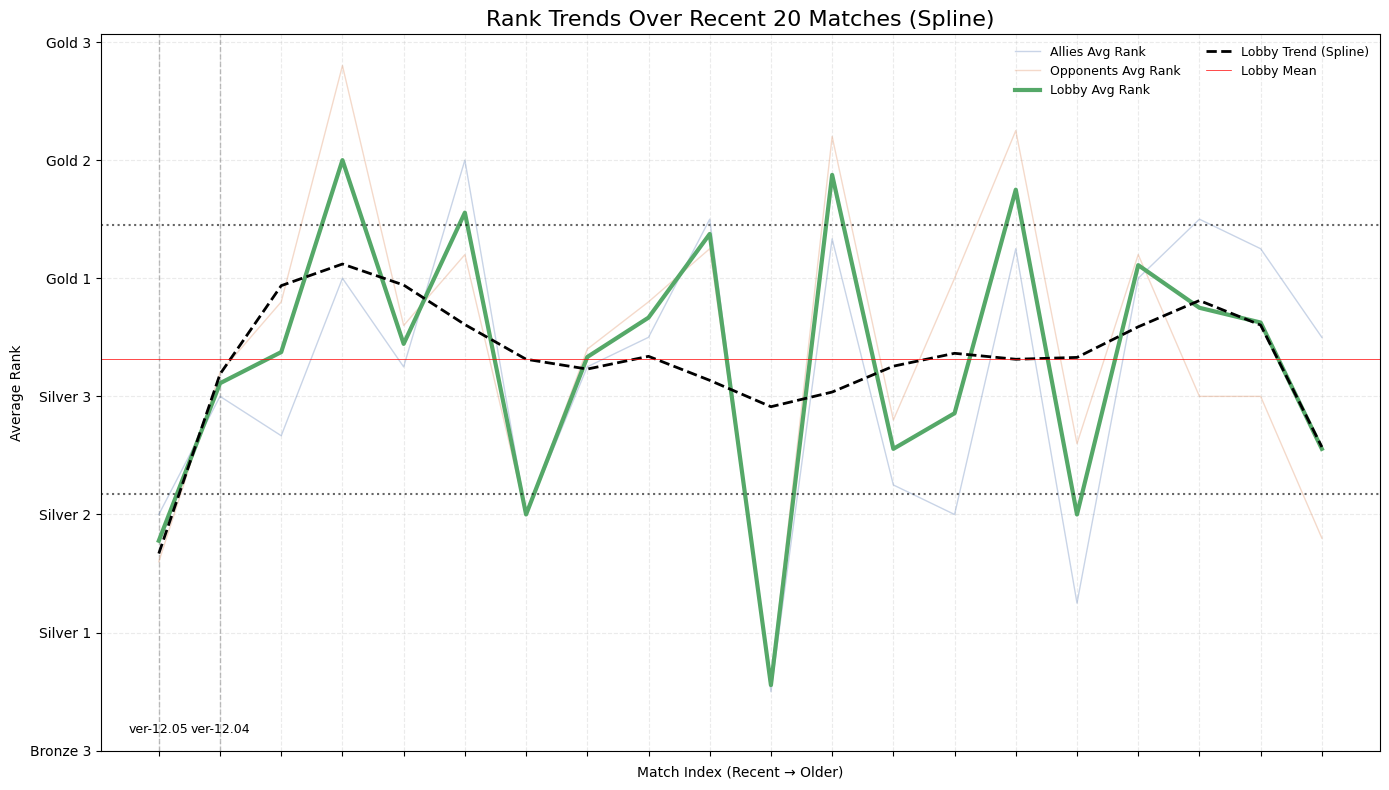

In [8]:
from matplotlib import pyplot as plt

def plot_rank_trends(
    rank_averages: Dict[str, List[Optional[float]]],
    recent_matches: List[Match],
    N: Optional[int] = None,
) -> None:
    """
    Plot ally / opponent / lobby average ranks with a spline trend overlay.

    Parameters
    ----------
    rank_averages : dict
        Output of gather_rank_average_lists_spline.
    recent_matches : list[Match]
        Matches in the same order as rank_averages values.
    N : int | None
        Number of matches to show (default: all).
    """
    total_matches = len(next(iter(rank_averages.values())))
    game_versions = [recent_matches[i].metadata.game_version for i in range(total_matches)]
    game_versions = [
        ver[:ver.index('-shipping')].replace('release-', 'ver-')
        for ver in game_versions
    ]
    version_changes = find_change_indices(game_versions)

    end_idx = N or total_matches
    matches = np.arange(1, end_idx + 1)

    colors   = {"allies_avg_rank": "#4C72B0", "opponents_avg_rank": "#DD8452", "lobby_avg_rank": "#55A868"}
    emphasis = {"allies_avg_rank": 0.3,        "opponents_avg_rank": 0.3,        "lobby_avg_rank": 1.0}

    plt.figure(figsize=(14, 8))

    for idx, version in version_changes:
        if idx < end_idx:
            plt.axvline(x=idx + 1, color='gray', linestyle='--', alpha=0.5, linewidth=1)
            plt.text(idx + 1, 0.02, version, rotation=0, va='bottom', ha='center',
                     fontsize=9, transform=plt.gca().get_xaxis_transform())
    plt.xticks([], [])

    for field, values in rank_averages.items():
        if field == "lobby_std":
            continue
        y = np.array([v if v is not None else np.nan for v in values[:end_idx]])
        plt.plot(matches, y,
                 color=colors.get(field, "gray"),
                 linewidth=3 if field == "lobby_avg_rank" else 1,
                 alpha=emphasis.get(field, 0.5),
                 label=field.replace("_", " ").title())

        if field == "lobby_avg_rank" and (~np.isnan(y)).sum() >= 4:
            trend_y = np.array([
                v if v is not None else np.nan
                for v in (predict_mmr(rank_averages, i) for i in matches)
            ])
            plt.plot(matches, trend_y, linestyle="--", color="black",
                     linewidth=2, label="Lobby Trend (Spline)")

    # Mean ± 1σ
    lobby = np.array(rank_averages["lobby_avg_rank"][:end_idx], dtype=float)
    lobby = lobby[~np.isnan(lobby)]
    if len(lobby):
        mean, std = lobby.mean(), lobby.std()
        plt.axhline(mean,         color="red",   linewidth=0.5, alpha=1,   label="Lobby Mean")
        plt.axhline(mean + std,   color="black", linestyle=":", alpha=0.6)
        plt.axhline(mean - std,   color="black", linestyle=":", alpha=0.6)

    # Placement regions
    ax = plt.gca()
    placement_ranges = calculate_placement_regions(reverse=False, offset=1,
                                                    matches_selection=recent_matches)
    first = True
    for start, end in placement_ranges:
        ax.axvline(start, linestyle="--", linewidth=1)
        ax.axvline(end,   linestyle="--", linewidth=1)
        ax.axvspan(start - 0.5, end + 0.5, alpha=0.15,
                   label="Placement Matches" if first else None)
        first = False

    # Y-axis tick labels
    step = max(1, end_idx // 15)
    plt.xticks(matches[::step])
    all_values = [
        v for key, vals in rank_averages.items()
        if key != "lobby_std"
        for v in vals[:end_idx]
        if v is not None
    ]
    if all_values:
        y_min, y_max = int(np.floor(min(all_values))), int(np.ceil(max(all_values))) + 1
        y_ticks = np.arange(y_min, y_max, 1)
        plt.yticks(y_ticks, [lookup_rank(int(t)) for t in y_ticks])

    plt.title(f"Rank Trends Over Recent {end_idx} Matches (Spline)", fontsize=16)
    plt.xlabel("Match Index (Recent → Older)")
    plt.ylabel("Average Rank")
    plt.grid(True, linestyle="--", alpha=0.25)
    plt.legend(frameon=False, ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()


plot_rank_trends(rank_averages, recent_matches)


## 7 · Win Rate

In [9]:
wr = calculate_winrate(recent_matches, my_puuid)
print(f"{wr['wins']}W / {wr['losses']}L over {wr['games']} games  —  {wr['winrate']:.0%} win rate")


14W / 6L over 20 games  —  70% win rate


## 8 · Lobby Balance Analysis

Ranks all recent matches by how evenly matched the lobbies were, using the
standard deviation of ranks across all 9 other players as the balance metric.


In [10]:
results = analyze_match_history(rank_averages)

most_balanced_match  = recent_matches[results['lobby_balance']['most_balanced'][1]]
least_balanced_match = recent_matches[results['lobby_balance']['least_balanced'][1]]

print("Most balanced: ", most_balanced_match.metadata.url)
print("  std:", calculate_average_ranks_spline(most_balanced_match,  my_puuid, keep_lists=True)['lobby_std'])
print()
print("Least balanced:", least_balanced_match.metadata.url)
print("  std:", calculate_average_ranks_spline(least_balanced_match, my_puuid, keep_lists=True)['lobby_std'])


Most balanced:  https://vtl.lol/match/6f6eb5e4-2d33-487a-b033-0747a5c5e7e9
  std: (1.0540925533894598, [7, 9, 9, 6, 9, 9, 8, 9, 9])

Least balanced: https://vtl.lol/match/481e10f3-fd07-46af-bfee-70a6fff72b1e
  std: (2.1140330656044943, [10, 7, 5, 6, 7, 7, 10, 11, 5])


In [11]:
# All matches sorted by lobby balance (tightest → loosest)
matches_by_balance = sort_matches_by_lobby_std(recent_matches, rank_averages['lobby_std'])
for score, game in matches_by_balance:
    print(f"{score:.3f}  {game.metadata.url}")


1.054  https://vtl.lol/match/6f6eb5e4-2d33-487a-b033-0747a5c5e7e9
1.155  https://vtl.lol/match/59d344f9-2b6a-4309-9838-56e38c1b6fa3
1.165  https://vtl.lol/match/aa65b4c4-d6e7-4d99-9dd3-0019b0eb61d8
1.218  https://vtl.lol/match/c0c25890-0fa5-4980-bcdb-91c5e5725245
1.218  https://vtl.lol/match/24a27522-e79d-44e6-bea9-69b53675f0a9
1.227  https://vtl.lol/match/ddcd7a54-1c56-41bf-a88a-8dd304a83d90
1.333  https://vtl.lol/match/93c4efa6-cefb-453f-9055-7b55bf1600f6
1.392  https://vtl.lol/match/f324b654-a732-4954-9d25-fe390a7d090c
1.423  https://vtl.lol/match/0e7fe821-ad84-4bfc-8478-6efa2e19d5e7
1.449  https://vtl.lol/match/e92403f7-e113-46de-aea3-e0b970a5e39a
1.499  https://vtl.lol/match/3f858d54-e84f-4e38-b445-f0d3c770e12d
1.523  https://vtl.lol/match/8f62d408-7978-4d0c-9c0d-14a75e838bdf
1.536  https://vtl.lol/match/63fd6543-6bea-40d8-8e69-e7f1327c86e7
1.633  https://vtl.lol/match/ab10b950-f41f-4cd5-9f19-03591154b838
1.641  https://vtl.lol/match/a1586d4b-7993-454a-b7cd-e0e82759e1f7
1.654  htt

### Lobby Std Distribution

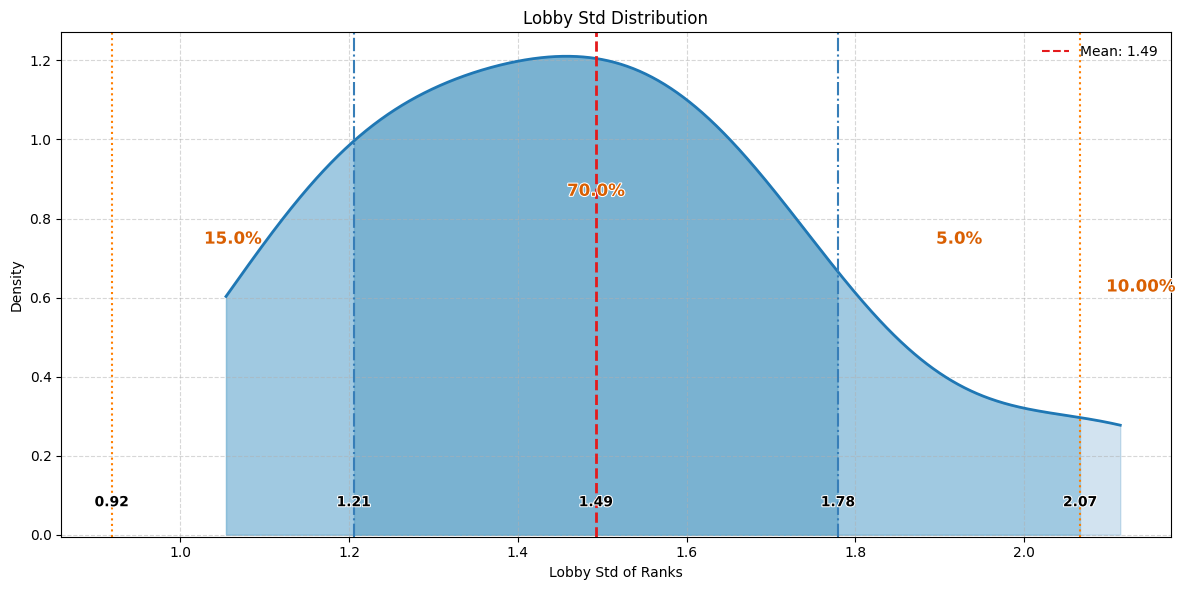

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import seaborn as sns
from scipy.stats import gaussian_kde

lobby_std  = np.array(rank_averages['lobby_std'])
mean_std   = np.mean(lobby_std)
std_std    = np.std(lobby_std)

colors = {
    'kde_curve':    '#1f77b4',
    'shade_1sigma': '#6aa9cb',
    'shade_2sigma': '#6fb0d3',
    'mean_line':    '#e41a1c',
    'line_1sigma':  '#377eb8',
    'line_2sigma':  '#ff7f00',
    'text':         '#d95f02',
}

kde = gaussian_kde(lobby_std)
x   = np.linspace(lobby_std.min(), lobby_std.max(), 1000)
y   = kde(x)

plt.figure(figsize=(12, 6))
plt.plot(x, y, color=colors['kde_curve'], lw=2)
plt.fill_between(x, 0, y, color=colors['kde_curve'], alpha=0.2)
plt.fill_between(x, 0, y,
                 where=(x >= mean_std - 2*std_std) & (x <= mean_std + 2*std_std),
                 color=colors['shade_2sigma'], alpha=0.5)
plt.fill_between(x, 0, y,
                 where=(x >= mean_std - std_std) & (x <= mean_std + std_std),
                 color=colors['shade_1sigma'], alpha=0.7)

total = len(lobby_std)
pct_1s      = np.sum((lobby_std >= mean_std - std_std) & (lobby_std <= mean_std + std_std)) / total * 100
pct_l_1_2   = np.sum((lobby_std >= mean_std - 2*std_std) & (lobby_std < mean_std - std_std)) / total * 100
pct_r_1_2   = np.sum((lobby_std > mean_std + std_std) & (lobby_std <= mean_std + 2*std_std)) / total * 100
pct_beyond_l = np.sum(lobby_std < mean_std - 2*std_std) / total * 100
pct_beyond_r = np.sum(lobby_std > mean_std + 2*std_std) / total * 100

vlines = {'Mean': mean_std, '+1σ': mean_std+std_std, '-1σ': mean_std-std_std,
          '+2σ': mean_std+2*std_std, '-2σ': mean_std-2*std_std}
for label, x_val in vlines.items():
    ls = '--' if label == 'Mean' else ('-.' if '1σ' in label else ':')
    col = colors['mean_line'] if label == 'Mean' else (colors['line_1sigma'] if '1σ' in label else colors['line_2sigma'])
    plt.axvline(x_val, color=col, linestyle=ls, lw=1.5 + (0.5 if label == 'Mean' else 0))
    txt = plt.text(x_val, 0.1, f'{x_val:.2f}', ha='center', va='top', fontsize=10, color='black', fontweight='bold')
    txt.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'), path_effects.Normal()])

def annotate(x_pos, y_pos, text):
    txt = plt.text(x_pos, y_pos, text, ha='center', va='bottom',
                   fontsize=12, fontweight='bold', color=colors['text'])
    txt.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'), path_effects.Normal()])

annotate(mean_std,               max(y)*0.7, f'{pct_1s:.1f}%')
annotate(mean_std - 1.5*std_std, max(y)*0.6, f'{pct_l_1_2:.1f}%')
annotate(mean_std + 1.5*std_std, max(y)*0.6, f'{pct_r_1_2:.1f}%')
if pct_beyond_l > 0: annotate(mean_std - 2.25*std_std, max(y)*0.5, f'{pct_beyond_l:.2f}%')
if pct_beyond_r > 0: annotate(mean_std + 2.25*std_std, max(y)*0.5, f'{pct_beyond_r:.2f}%')

plt.title("Lobby Std Distribution")
plt.xlabel("Lobby Std of Ranks")
plt.ylabel("Density")
plt.ylim(-0.005)
plt.legend(handles=[plt.Line2D([0],[0], color=colors['mean_line'], linestyle='--', label=f'Mean: {mean_std:.2f}')],
           frameon=False)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [13]:
# What fraction of matches were "tight" (std ≤ threshold)?
threshold = 1.16
pct = len(slice_until_value(matches_by_balance, threshold)) / len(matches_by_balance)
print(f"{pct:.1%} of matches had lobby spread ≤ {threshold} std")


10.0% of matches had lobby spread ≤ 1.16 std


## 9 · RR Model & Match Ledger

`build_match_ledger` walks through `recent_mmr` in chronological order and
records what *actually* happened vs what the API says was supposed to happen.
It also flags:

- **Splices** — a jump of >42 RR implies matches are missing from the history
- **Shields** — ELO unchanged on a reported loss (rank shield consumed)
- **Buffers** — loss stopped at a tier boundary (demotion protection)
- **Big losses** — ≥30 RR lost in a single game
- **RR desync** — actual delta ≠ reported `last_mmr_change` by ≥10 RR


In [14]:
SPLICE_THRESHOLD_RR   = 42
BIG_LOSS_THRESHOLD_RR = 30
RR_DESYNC_THRESHOLD   = 10

def build_match_ledger(
    recent_mmr: Dict[str, 'V1LifetimeMmrHistoryItem'],
) -> Dict[str, dict]:
    """
    Build a per-match-id dict capturing ELO deltas and anomaly flags.

    Keys per entry:
      elo_before, elo_after, tier_before, tier_after,
      rr_supposed_to_take, rr_actual_taken,
      shield_used, buffer_used, is_splice, big_loss, rr_desync,
      datecode, map, match_data, is_placement, is_newly_placed_rank,
      predicted_mmr
    """
    ledger = {}
    matches = list(reversed(recent_mmr.items()))   # oldest → newest

    prev_elo_after  = None
    prev_tier_after = None

    for match_id, match in matches:
        elo_after  = match.elo
        tier_after = match.tier.name
        elo_before = prev_elo_after
        tier_before = prev_tier_after

        if recent_is_placement[match_id]:
            elo_before = get_last_known_elo(match_id)
            if elo_after == 0:
                elo_after = get_last_known_elo(match_id)

        rr_supposed_take = match.last_mmr_change
        rr_actual_taken  = None
        shield_used = buffer_used = is_splice = big_loss = rr_desync = False

        if elo_before is not None:
            rr_actual_taken = elo_after - elo_before

            if abs(rr_actual_taken) > SPLICE_THRESHOLD_RR:
                # Data gap — invalidate continuity for this entry
                is_splice        = True
                rr_supposed_take = rr_actual_taken
                elo_before       = None
                tier_before      = None
                rr_actual_taken  = None
                prev_elo_after   = elo_after
                prev_tier_after  = tier_after
            else:
                if match.last_mmr_change <= -BIG_LOSS_THRESHOLD_RR:
                    big_loss = True

                if (match.last_mmr_change < 0
                        and elo_after % 100 == 0
                        and elo_before % 100 != 0
                        and match.last_mmr_change != rr_actual_taken):
                    buffer_used = True

                if match.last_mmr_change < 0 and elo_after == elo_before:
                    shield_used = True

                if match.last_mmr_change is not None:
                    delta = abs(rr_actual_taken - match.last_mmr_change)
                    if delta >= RR_DESYNC_THRESHOLD:
                        is_rankup = tier_after != tier_before and elo_after % 100 == 10
                        if not (is_rankup or shield_used or buffer_used):
                            rr_desync = True

                prev_elo_after  = elo_after
                prev_tier_after = tier_after
        else:
            prev_elo_after  = elo_after
            prev_tier_after = tier_after

        prev_match_id       = recent_previous_match[match_id]
        is_placement        = recent_is_placement[match_id]
        is_newly_placed_rank = (
            match.ranking_in_tier != 0 and recent_is_placement[prev_match_id]
            if prev_match_id is not None else False
        )

        ledger[match.match_id] = {
            'elo_before':          elo_before,
            'elo_after':           elo_after,
            'tier_before':         tier_before,
            'tier_after':          tier_after,
            'rr_supposed_to_take': rr_supposed_take,
            'rr_actual_taken':     rr_actual_taken,
            'shield_used':         shield_used,
            'buffer_used':         buffer_used,
            'is_splice':           is_splice,
            'big_loss':            big_loss,
            'rr_desync':           rr_desync and not is_newly_placed_rank,
            'datecode':            match.datetime,
            'map':                 match.map.name,
            'match_data':          match,
            'is_placement':        is_placement or is_newly_placed_rank,
            'is_newly_placed_rank': is_newly_placed_rank,
            'predicted_mmr':       predicted_matches_mmr[match.match_id] * 100,
        }

    return ledger


ledger = build_match_ledger(recent_mmr)
print(f"Ledger built: {len(ledger)} entries")


Ledger built: 20 entries


## 10 · Counterfactual Analysis

Simulates what the player's rank progression would look like under two
alternative scenarios:

| Scenario | What changes |
|---|---|
| **No-buffer** | Demotion protection is removed; losses can cross tier boundaries |
| **Adjusted** | RR values are also rescaled via `predict_rr_change` based on estimated MMR at that point |

The big visualisation below overlays the actual path against the counterfactual
path and annotates every notable event.


In [15]:
def compute_counterfactual_path(ledger_entries: list, model_adjustments: bool = False) -> list:
    """
    Simulate rank progression with Valorant's demotion buffer intact.

    Parameters
    ----------
    ledger_entries : list[dict]
        Chronological ledger entries (output of build_match_ledger).
    model_adjustments : bool
        If True, rescale RR changes via predict_rr_change based on estimated MMR.

    Returns
    -------
    list[int]
        Simulated ELO after each match.
    """
    first_entry = next(e for e in ledger_entries if e['elo_before'] is not None)
    current_elo = first_entry['elo_before']
    result      = []

    for entry in ledger_entries:
        match_id          = entry['match_data'].match_id
        rr_change         = entry['rr_supposed_to_take'] or 0
        is_newly_placed   = entry['is_newly_placed_rank']

        if model_adjustments and not recent_is_placement[match_id]:
            rr_change = predict_rr_change(
                rr_change,
                entry['elo_before'],
                predicted_matches_mmr[match_id] * 100,
                current_elo,
            )

        # Demotion buffer: don't let a loss cross a tier boundary
        if rr_change < 0 and not entry['is_splice']:
            remainder = current_elo % 100
            max_loss  = -remainder if remainder != 0 else rr_change
            rr_change = max(rr_change, max_loss)

        next_elo = current_elo + rr_change

        # Promotion bonus (land at x10 after tier crossing)
        if next_elo // 100 > current_elo // 100:
            r = next_elo % 100
            if r < 10:
                next_elo += 10 - r

        if is_newly_placed or recent_is_placement[match_id]:
            elo_after = entry['elo_after']
            next_elo  = elo_after if elo_after is not None else current_elo
        else:
            next_elo = min(next_elo, entry['elo_after'])

        result.append(next_elo)
        current_elo = next_elo

    return result


def compute_counterfactual_nobuffer_path(ledger_entries: list, model_adjustments: bool = False) -> list:
    """
    Simulate rank progression *without* Valorant's demotion buffer.

    Parameters match `compute_counterfactual_path`; see that docstring.
    """
    first_entry = next(e for e in ledger_entries if e['elo_before'] is not None)
    current_elo = first_entry['elo_before']
    result      = []

    for entry in ledger_entries:
        match_id        = entry['match_data'].match_id
        rr_change       = entry['rr_supposed_to_take'] or 0
        is_newly_placed = entry['is_newly_placed_rank']

        if model_adjustments and not recent_is_placement[match_id]:
            rr_change = predict_rr_change(
                rr_change,
                entry['elo_before'],
                predicted_matches_mmr[match_id] * 100,
                current_elo,
            )

        next_elo = current_elo + rr_change

        if is_newly_placed or recent_is_placement[match_id]:
            elo_after = entry['elo_after']
            next_elo  = elo_after if elo_after is not None else current_elo
        else:
            next_elo = min(next_elo, entry['elo_after'])

        result.append(next_elo)
        current_elo = next_elo

    return result


In [16]:
# Drop the oldest entry (no elo_before) and compute all four paths
ledger_entries = list(ledger.values())[1:]
actual_elos    = [e['elo_after'] for e in ledger_entries]

counterfactual_elos              = compute_counterfactual_path(ledger_entries)
counterfactual_elos_adj          = compute_counterfactual_path(ledger_entries, True)
counterfactual_nobuffer_elos     = compute_counterfactual_nobuffer_path(ledger_entries)
counterfactual_nobuffer_elos_adj = compute_counterfactual_nobuffer_path(ledger_entries, True)

match_indices = list(range(len(ledger_entries)))


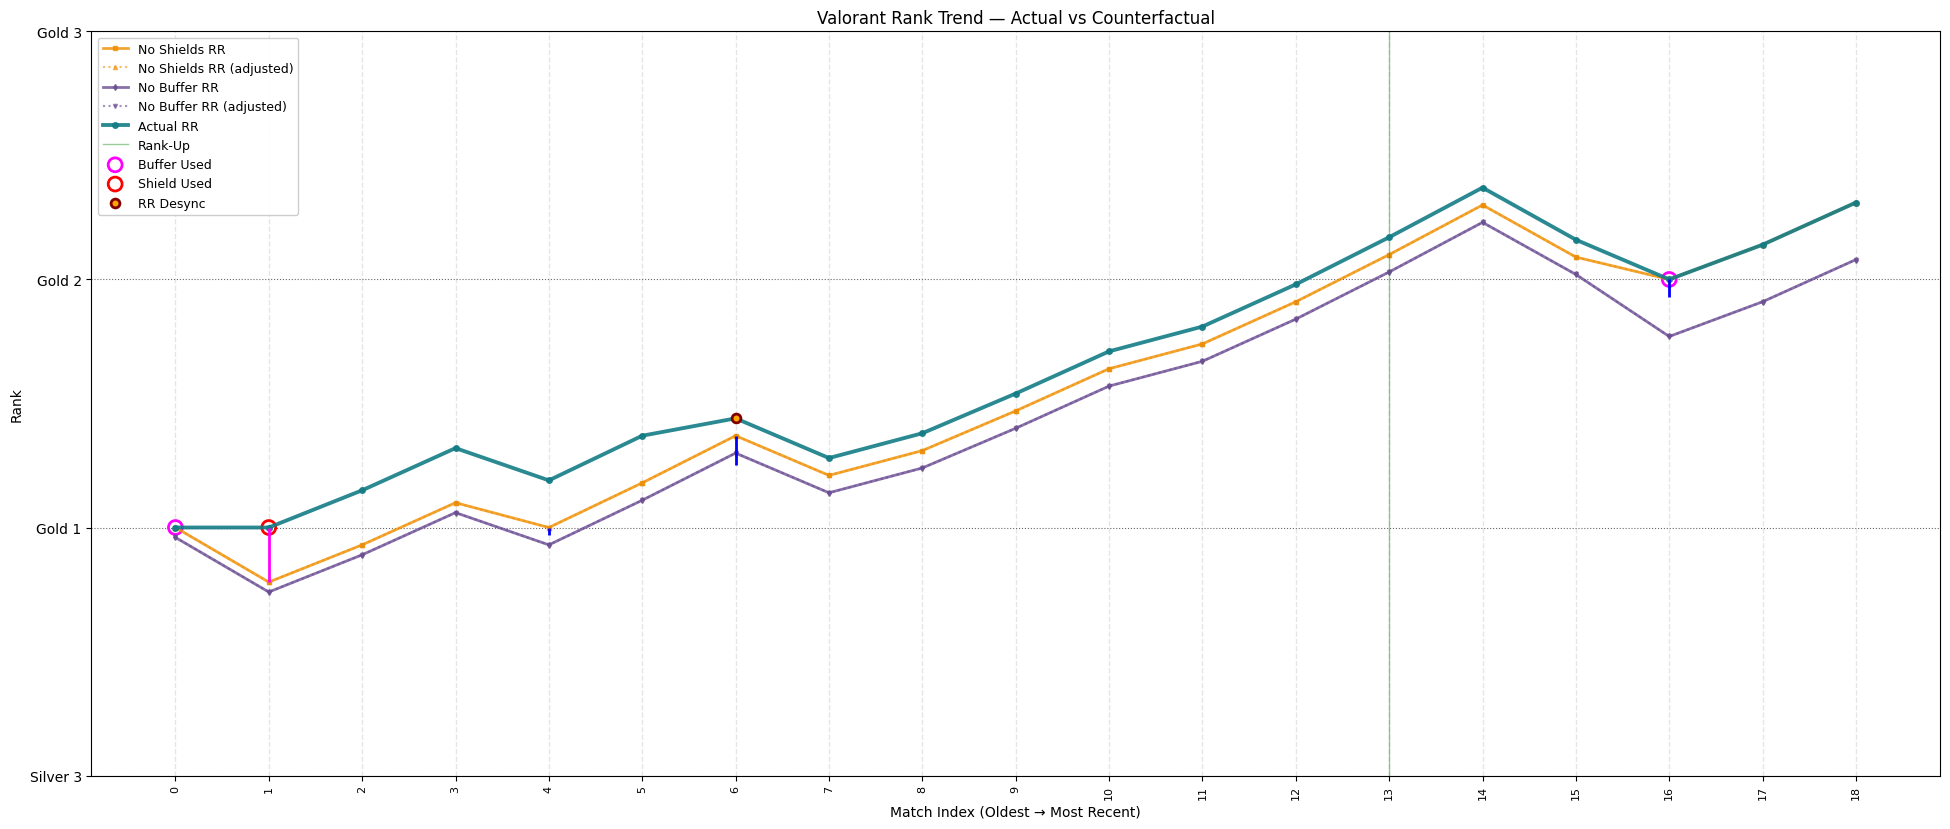

In [17]:
# ── Counterfactual visualisation ──────────────────────────────────────────────
WITH_NO_BUFFER = True
WITH_ADJ       = True

colors = {
    'actual':        "#147C86",
    'no_shields':    "#F18F01",
    'no_shields_adj':"#F18F01",
    'no_buffer':     '#6A4C93',
    'no_buffer_adj': "#6A4C93",
}

actual_elos_clean = [
    elo if elo is not None else counterfactual_nobuffer_elos_adj[i]
    for i, elo in enumerate(actual_elos)
]

all_plotted = [actual_elos_clean, counterfactual_elos]
if WITH_ADJ:       all_plotted.append(counterfactual_elos_adj)
if WITH_NO_BUFFER: all_plotted.append(counterfactual_nobuffer_elos)
if WITH_NO_BUFFER and WITH_ADJ: all_plotted.append(counterfactual_nobuffer_elos_adj)

min_elo = min(min(p) for p in all_plotted)
max_elo = max(max(p) for p in all_plotted)

fig, ax = plt.subplots(figsize=(14*1.4, 6*1.4))

# ── Counterfactual paths ───────────────────────────────────────────────────
ax.plot(match_indices, counterfactual_elos,
        label="No Shields RR", linestyle='-',
        color=colors['no_shields'], linewidth=2, marker="s", markersize=3, alpha=0.8)

if WITH_ADJ:
    ax.plot(match_indices, counterfactual_elos_adj,
            label="No Shields RR (adjusted)", linestyle=':',
            color=colors['no_shields_adj'], linewidth=1.5, marker="^", markersize=3, alpha=0.6)

if WITH_NO_BUFFER:
    ax.plot(match_indices, counterfactual_nobuffer_elos,
            label="No Buffer RR", linestyle='-',
            color=colors['no_buffer'], linewidth=2, marker="d", markersize=3, alpha=0.8)
    if WITH_ADJ:
        ax.plot(match_indices, counterfactual_nobuffer_elos_adj,
                label="No Buffer RR (adjusted)", linestyle=':',
                color=colors['no_buffer_adj'], linewidth=1.5, marker="v", markersize=3, alpha=0.6)

# ── Actual path (on top) ───────────────────────────────────────────────────
ax.plot(match_indices, actual_elos_clean,
        label="Actual RR", color=colors['actual'], linewidth=2.75,
        marker="o", markersize=4, zorder=100, alpha=0.9)

# ── Per-match shield/buffer delta contributions ────────────────────────────
# Draws a vertical bar at each match showing how much the shield/buffer moved
# the actual ELO relative to the no-shields counterfactual.
previous_delta = 0
for i, (cf, actual) in enumerate(zip(counterfactual_elos, actual_elos_clean)):
    individual_delta = (actual - cf) - previous_delta
    previous_delta  += individual_delta
    if individual_delta != 0 and abs(individual_delta) < 100:
        if individual_delta > 0:
            ymin, ymax, bar_color = cf, cf + individual_delta, "magenta"
        else:
            ymin, ymax, bar_color = cf + individual_delta, cf, "blue"
        ax.vlines(x=i, ymin=ymin, ymax=ymax,
                  colors=bar_color, linestyles='solid', linewidth=2, zorder=100)

# ── Rank tier horizontal grid ──────────────────────────────────────────────
for rname in VALORANT_RANKS:
    for target in ["Bronze", "Silver", "Gold", "Platinum", "Diamond", "Ascendant"]:
        if target in rname:
            ax.axhline(VALORANT_RANKS.index(rname) * 100,
                       color="black", linestyle=":", linewidth=0.8, alpha=0.6, zorder=0)

# Faint vertical match lines
for x in match_indices:
    ax.axvline(x, color='gray', linestyle='dashed', alpha=0.2, linewidth=1)

# Rank-up / derank lines
rank_up_plotted = derank_plotted = False
for i, entry in enumerate(ledger_entries):
    if entry['elo_after'] is None or entry['elo_before'] is None:
        continue
    if entry['tier_after'] != entry['tier_before'] and entry['tier_before'] is not None:
        if entry['elo_after'] > entry['elo_before']:
            ax.axvline(i, color='green', alpha=0.4, linestyle='-', linewidth=1,
                       label="Rank-Up" if not rank_up_plotted else "")
            rank_up_plotted = True
        else:
            ax.axvline(i, color='red', alpha=0.4, linestyle='-', linewidth=1,
                       label="Derank" if not derank_plotted else "")
            derank_plotted = True

# Placement shading
placement_ranges = calculate_placement_regions(reverse=True, offset=-1)
first = True
for start, end in placement_ranges:
    ax.axvline(start, linestyle="--", linewidth=1)
    ax.axvline(end,   linestyle="--", linewidth=1)
    ax.axvspan(start - 0.5, end + 0.5, alpha=0.15,
               label="Placement Matches" if first else None)
    first = False

# Event annotations
events = {
    'splice':               dict(cond=lambda e: e.get('is_splice'),
                                 plot='axvline', color='black', linewidth=2, alpha=0.4, linestyle='--',
                                 label="Data Splice"),
    'shield':               dict(cond=lambda e: e.get('shield_used'),
                                 plot='scatter', s=100, facecolors='none', edgecolors='red',
                                 linewidths=2, label="Shield Used"),
    'rr_desync':            dict(cond=lambda e: e.get('rr_desync'),
                                 plot='scatter', s=40, facecolors='orange', edgecolors='maroon',
                                 zorder=100, linewidths=2, label="RR Desync"),
    'is_newly_placed_rank': dict(cond=lambda e: e.get('is_newly_placed_rank'),
                                 plot='scatter', s=40, facecolors='orange', edgecolors='teal',
                                 zorder=100, linewidths=2, label="Newly Placed Rank"),
    'buffer':               dict(cond=lambda e: e.get('buffer_used') and not e.get('shield_used'),
                                 plot='scatter', s=100, facecolors='none', edgecolors='magenta',
                                 linewidths=2, label="Buffer Used"),
    'big_loss':             dict(cond=lambda e: e.get('big_loss'),
                                 plot='scatter', marker='*', s=67, color='#CAD40D',
                                 edgecolors='black', linewidths=0.8, zorder=100,
                                 label=f"Big Loss (≥{BIG_LOSS_THRESHOLD_RR} RR)"),
}
plotted = {k: False for k in events}
for i, e in enumerate(ledger_entries):
    for k, v in events.items():
        if v['cond'](e):
            kw = {kk: vv for kk, vv in v.items() if kk not in ('cond', 'plot')}
            if plotted[k]:
                kw.pop('label', None)
            plotted[k] = True
            if v['plot'] == 'axvline':
                ax.axvline(i, **kw)
            else:
                ax.scatter(i, e['elo_after'], **kw)

# ── Axes ───────────────────────────────────────────────────────────────────
ax.set_ylim(min_elo - 10, max_elo + 10)
yticks  = list(range((min_elo//100)*100, ((max_elo//100)+2)*100, 100))
ylabels = [map_rank_value(v/100, include_rr=False) if v > 0 else "" for v in yticks]
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.set_xticks(match_indices)
ax.set_xticklabels(match_indices, rotation=90, fontsize=8)
ax.set_xlabel("Match Index (Oldest → Most Recent)")
ax.set_ylabel("Rank")
ax.set_title("Valorant Rank Trend — Actual vs Counterfactual")
ax.legend(loc='best', framealpha=0.95, fontsize=9)
plt.tight_layout()
plt.show()


## 11 · Summary

In [18]:
last_match_id      = recent_matches[0].metadata.match_id
prev_match_id      = recent_matches[1].metadata.match_id
estimated_mmr      = predicted_matches_mmr[last_match_id] * 100
current_elo        = recent_mmr[prev_match_id].elo
counter_elo        = counterfactual_nobuffer_elos_adj[-2]
last_rr            = recent_mmr[last_match_id].last_mmr_change
counter_rr         = predict_rr_change(last_rr, current_elo, estimated_mmr, counter_elo)

print(f"Current MMR:                        {map_rank_value(estimated_mmr / 100)}")
print(f"Current Rank:                       {map_rank_value(current_elo / 100)}")
print(f"Counterfactual Rank (no-buffer+adj):{map_rank_value(counter_elo / 100)}")
print()
print(f"As {map_rank_value(current_elo/100)}, earned {last_rr:+d} RR last match.")
print(f"As {map_rank_value(counter_elo/100)}, would have earned {counter_rr:+d} RR.")


Current MMR:                        Bronze 3 55 RR
Current Rank:                       Gold 2 14 RR
Counterfactual Rank (no-buffer+adj):Gold 1 91 RR

As Gold 2 14 RR, earned +17 RR last match.
As Gold 1 91 RR, would have earned +17 RR.


## 12 · Agent Stats & HTML Report

Aggregates per-agent statistics across all recent matches (opponent teams only)
and writes an interactive sortable HTML page.


In [19]:
# Quick check: how often did each role appear on opponent teams?
role_pcts = calculate_role_percentages(recent_matches, my_puuid)
for role, pct in sorted(role_pcts.items()):
    print(f"  {role:<12} {pct}")


  Controller   100.0%
  Duelist      100.0%
  Initiator    65.0%
  Sentinel     100.0%


In [20]:
# Full agent stats dict (for custom queries)
agent_stats = calculate_agent_stats(recent_matches, my_puuid)
agent_stats


{'Sage': {'picks': 14,
  'teams': 14,
  'wins': 7,
  'kills': 220,
  'deaths': 216,
  'assists': 104,
  'matches_seen': 12},
 'Veto': {'picks': 5,
  'teams': 5,
  'wins': 2,
  'kills': 62,
  'deaths': 81,
  'assists': 9,
  'matches_seen': 5},
 'Neon': {'picks': 5,
  'teams': 5,
  'wins': 2,
  'kills': 85,
  'deaths': 77,
  'assists': 26,
  'matches_seen': 5},
 'Reyna': {'picks': 14,
  'teams': 14,
  'wins': 8,
  'kills': 254,
  'deaths': 240,
  'assists': 47,
  'matches_seen': 12},
 'Brimstone': {'picks': 4,
  'teams': 4,
  'wins': 3,
  'kills': 52,
  'deaths': 55,
  'assists': 35,
  'matches_seen': 4},
 'Skye': {'picks': 4,
  'teams': 4,
  'wins': 3,
  'kills': 56,
  'deaths': 44,
  'assists': 29,
  'matches_seen': 4},
 'Clove': {'picks': 20,
  'teams': 20,
  'wins': 11,
  'kills': 344,
  'deaths': 374,
  'assists': 107,
  'matches_seen': 13},
 'Gekko': {'picks': 3,
  'teams': 3,
  'wins': 1,
  'kills': 45,
  'deaths': 51,
  'assists': 6,
  'matches_seen': 3},
 'Jett': {'picks': 17,
 

In [21]:
# Generate the interactive HTML report
generate_html_report(recent_matches, my_puuid, output_file='index.html')


Report written to index.html
